In [ ]:
# demo KNN Classifier for Data Analysis
# Thanusyia Ramakrishnan
# Revision History
#
# -   -   -   -   -   -   -   -   -   -   -   -   -

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

location ='drive/MyDrive/ULoLI_Data_Analyst/Feb_Cohort/datafiles/'
list_of_files = os.listdir(location)
list_of_files

Mounted at /content/drive


['sports_class.csv',
 'solar_panel_compare.csv',
 'prostate_cancer_upd.csv',
 'LifeExpectancyData.csv',
 'heart.csv',
 'grades.csv',
 'grades.gsheet',
 'bmi_sample_data.csv',
 'bc_data-1.csv',
 'alaska-pipeline.csv',
 'heart.gsheet',
 'ca_ssi_peds_odp_2023.csv',
 'diabetes.csv',
 'loan_survey.csv']

In [ ]:
# import standard data science libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# cheat a little with the random state seed
from datetime import datetime
SEED = datetime.now().second



In [ ]:
# Download the loan survey file
loan_survey_df = pd.read_csv(location+'loan_survey.csv')


In [ ]:
# Summary of the DataFrame
print(loan_survey_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


In [ ]:
loan_survey_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# Decribe of the loan survey file
loan_survey_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


array([[<Axes: title={'center': 'ApplicantIncome'}>,
        <Axes: title={'center': 'CoapplicantIncome'}>],
       [<Axes: title={'center': 'LoanAmount'}>,
        <Axes: title={'center': 'Loan_Amount_Term'}>],
       [<Axes: title={'center': 'Credit_History'}>, <Axes: >]],
      dtype=object)

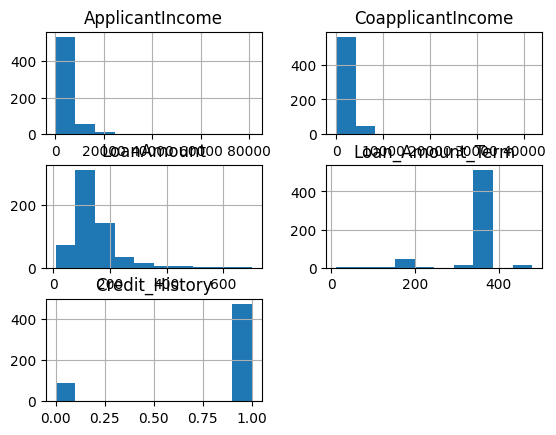

In [ ]:
# Describe of the histogram
loan_survey_df.hist()

Column 'Outcome' not found in the DataFrame. Plotting without hue.


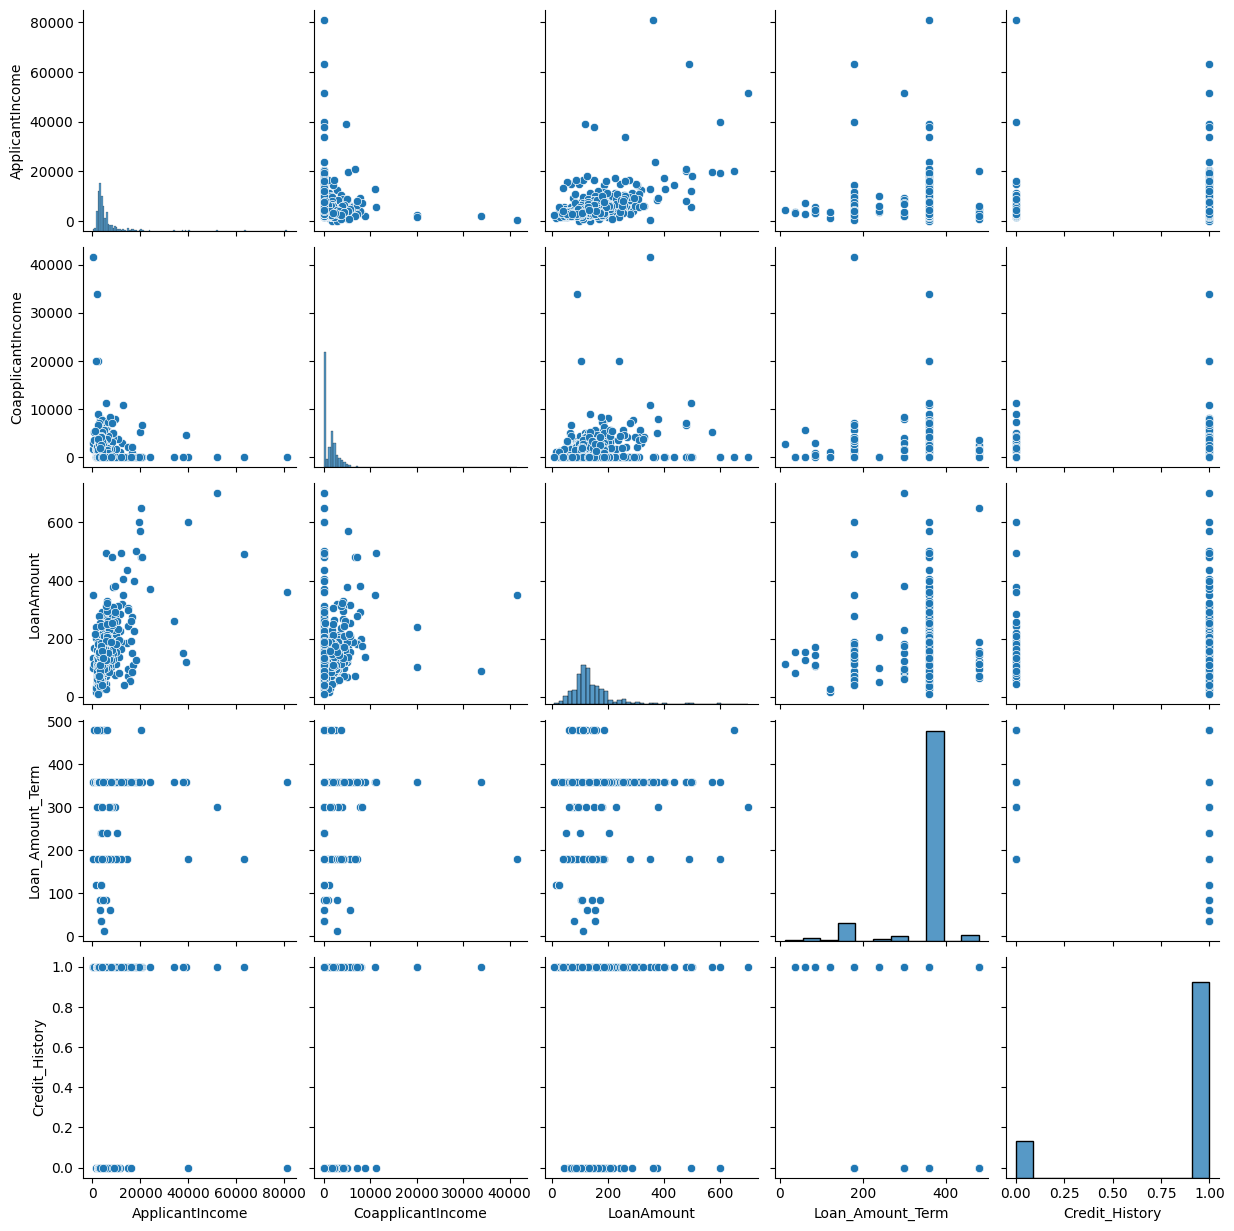

In [ ]:
# Create a pair of plot patterns
import seaborn as sns

# Check if 'Outcome' column exists before plotting
if 'Outcome' in loan_survey_df.columns:
    SNS_PLOT = sns.pairplot(loan_survey_df, hue='Outcome')
else:
    print("Column 'Outcome' not found in the DataFrame. Plotting without hue.")
    SNS_PLOT = sns.pairplot(loan_survey_df)

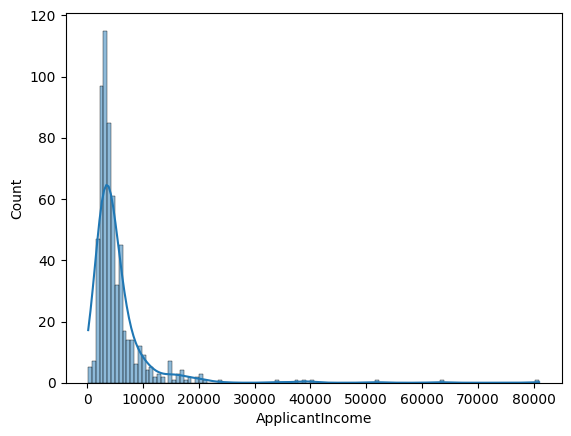

In [ ]:
# Plotting a histogram with a KDE
sns.histplot(loan_survey_df['ApplicantIncome'], kde=True)
plt.show()

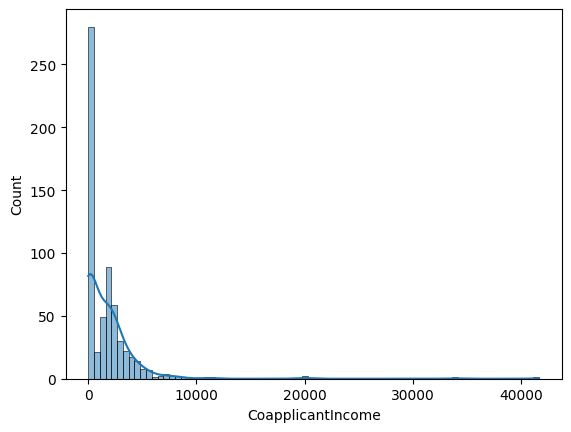

In [ ]:
# Plotting a histogram with a KDE
sns.histplot(loan_survey_df['CoapplicantIncome'], kde=True)
plt.show()

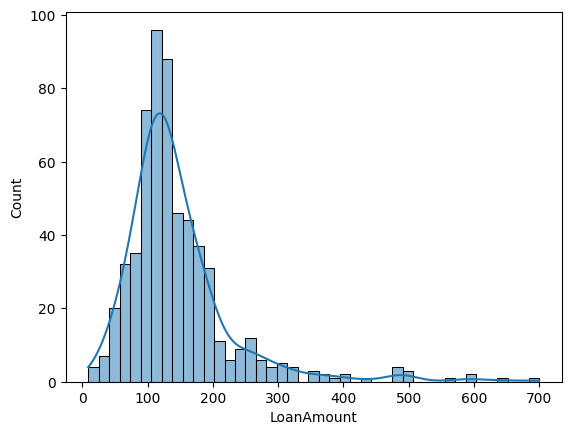

In [ ]:
# Plotting a histogram with a KDE
sns.histplot(loan_survey_df['LoanAmount'], kde=True)
plt.show()

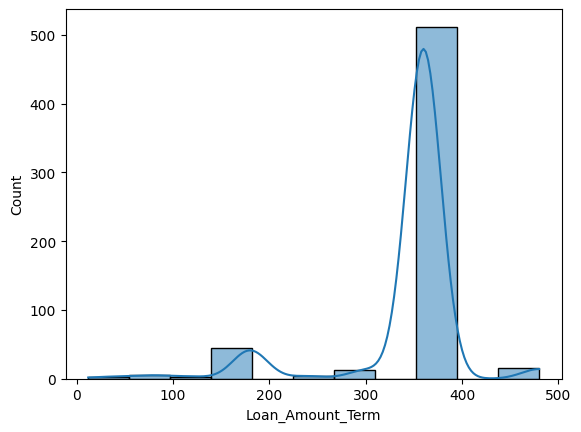

In [ ]:
# Plotting a histogram with a KDE
sns.histplot(loan_survey_df['Loan_Amount_Term'], kde=True)
plt.show()

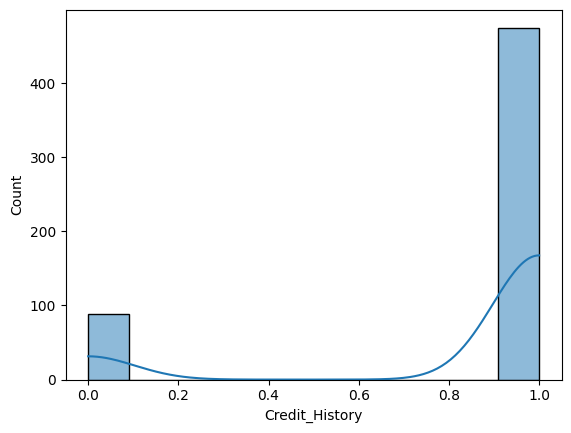

In [ ]:
# Plotting a histogram with a KDE
sns.histplot(loan_survey_df['Credit_History'], kde=True)
plt.show()

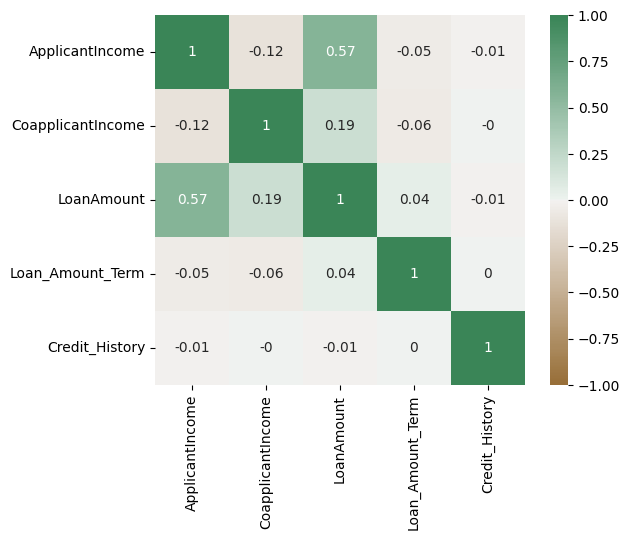

<Figure size 2000x2000 with 0 Axes>

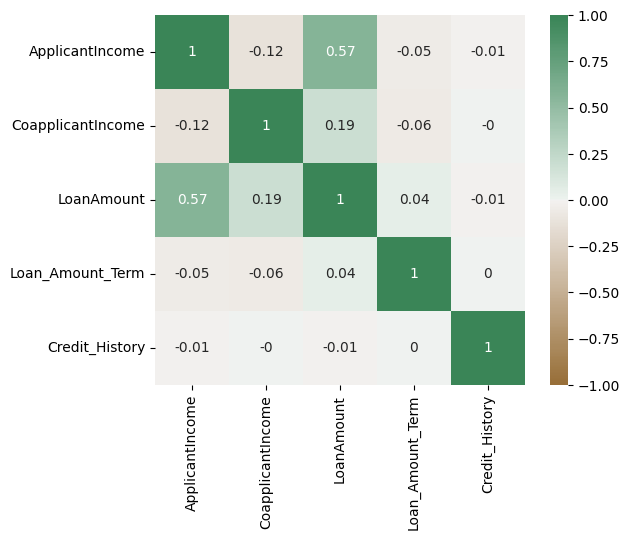

<Figure size 2000x2000 with 0 Axes>

In [ ]:
# Display the correlation as a heatmap.
# use matrix fields only
df_numeric = loan_survey_df.select_dtypes(include=np.number)

# create the correlation matrix
corr_Matrix = round(df_numeric.corr(),2)

# chart the correlation as a heatmap
axis_corr = sns.heatmap(corr_Matrix, vmin=-1,
                        vmax=1, center=0,
                        cmap=sns.diverging_palette(50, 500, n=500), \
                        square=True,
                        annot=True)
plt.figure(figsize=(20,20))
plt.show()

corr_Matrix = round(df_numeric.corr(),2)

# chart the correlation as a heatmap
axis_corr = sns.heatmap(corr_Matrix, vmin=-1,
                        vmax=1, center=0,
                        cmap=sns.diverging_palette(50, 500, n=500), \
                        square=True,
                        annot=True)
plt.figure(figsize=(20,20))
plt.show()

In [ ]:
# import specific libraries for AI / ML
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, \
ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, f1_score, roc_auc_score

In [ ]:
def loadDataIris():
  x_features = load_iris(return_X_y=False, as_frame=True).data
  y_targets = load_iris(return_X_y=False, as_frame=True).target
  return x_features, y_targets.values.ravel()

def loadData(ln, fn):
  df = pd.read_csv(ln+fn)
  y_targets  = df.iloc[:,-1:]     # assumes that the last column is the y_targets
  X_features = df.iloc[:,:-1]     # assumes that all the other columns are X_features
  return X_features, y_targets.values.ravel()


In [ ]:
# Load the X - Features and the y - observations
# X, y = loadDataIris()
filename = 'loan_survey.csv'
if filename in list_of_files:
  X, y = loadData(location, filename)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# get the numberic values only from X
X = X.select_dtypes(include='number')

# import train_test_split here to make it accessible
from sklearn.model_selection import train_test_split

# split the data set into a training set and a test set
# the reason you do this is to test the model to see how accurate
# in will perform when predicting the classifications
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.3, random_state=SEED)

In [ ]:
# Next import the AI / ML model you want to use
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# create the model
model = KNeighborsClassifier(n_neighbors=5)
# model = GaussianNB()
# model = SVC()
# model = DecisionTreeClassifier()
# model = RandomForestClassifier()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# train the model
from sklearn.model_selection import train_test_split

# get the numberic values only from X
X = X.select_dtypes(include='number')

# Impute missing values using SimpleImputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean') # You can change the strategy if needed
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns) # Apply imputation and convert back to DataFrame

# import train_test_split here to make it accessible
from sklearn.model_selection import train_test_split

# split the data set into a training set and a test set
# the reason you do this is to test the model to see how accurate
# in will perform when predicting the classifications
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.3, random_state=SEED)

In [ ]:
# model Bayes
model = GaussianNB()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
performance = accuracy_score(y_predict, y_test)
performance

0.7434944237918215

In [ ]:
# model KNeighborsClassifier(n_neighbors=5)
from sklearn.metrics import accuracy_score # Import accuracy_score from sklearn.metrics
model = KNeighborsClassifier()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
performance = accuracy_score(y_predict, y_test)
performance

0.6372093023255814

In [ ]:
# model GaussianNB(n_neighbors=5)
from sklearn.metrics import accuracy_score # Import accuracy_score from sklearn.metrics
model = GaussianNB()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
performance = accuracy_score(y_predict, y_test)
performance

0.7790697674418605

In [ ]:
# model DecisionTreeClassifier()
from sklearn.metrics import accuracy_score # Import accuracy_score from sklearn.metrics
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
performance = accuracy_score(y_predict, y_test)
performance

0.7558139534883721

In [ ]:
# model RandomForestClassifier()
from sklearn.metrics import accuracy_score # Import accuracy_score from sklearn.metrics
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_predict = model.predict(X_test)
performance = accuracy_score(y_predict, y_test)
performance

0.7953488372093023

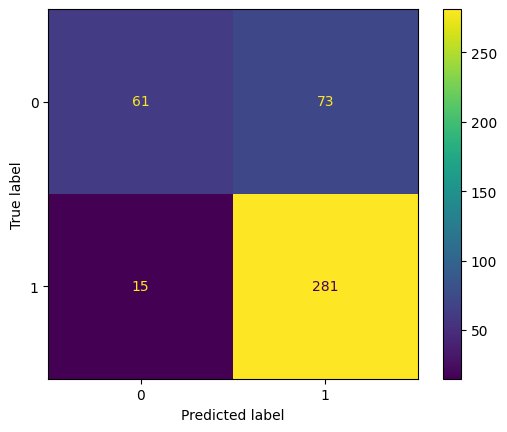

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

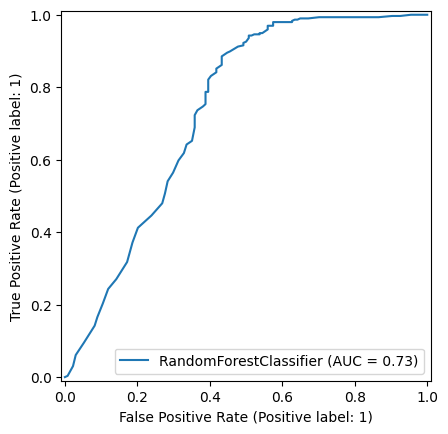

In [ ]:
# Import the necessary class
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_test, y_test)

In [ ]:
# Import roc_auc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, model.predict(X_test))

0.7022741024606696

In [ ]:
# Import the f1_score function from sklearn.metrics
from sklearn.metrics import f1_score

# Now you can use the f1_score function
f1_score(y_test, model.predict(X_test))

0.8646153846153846

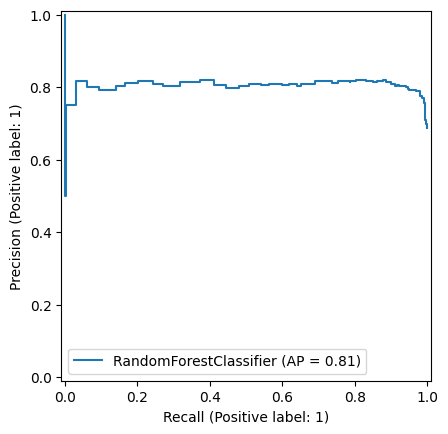

In [ ]:
# Import the necessary class
from sklearn.metrics import PrecisionRecallDisplay

# Now you can use the PrecisionRecallDisplay class
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)

In [ ]:
# Import the necessary class
from sklearn.metrics import classification_report, RocCurveDisplay, roc_auc_score, f1_score, PrecisionRecallDisplay

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.46      0.58       134
           1       0.79      0.95      0.86       296

    accuracy                           0.80       430
   macro avg       0.80      0.70      0.72       430
weighted avg       0.80      0.80      0.78       430

